In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("furth3r/facebook-ab-test-of-bidding-feature")

print("Path to dataset files:", path)

/Users/tmchq/Dev/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 1.25k/1.25k [00:00<00:00, 629kB/s]

Extracting files...
Path to dataset files: /Users/tmchq/.cache/kagglehub/datasets/furth3r/facebook-ab-test-of-bidding-feature/versions/1


In [3]:
import os
print(os.listdir(path + '/ab_test'))

['test_group.csv', 'control_group.csv']


In [4]:
import pandas as pd

control = pd.read_csv(path + '/ab_test/control_group.csv')
test = pd.read_csv(path + '/ab_test/test_group.csv')

print(control.shape, test.shape)
print(control.head())
print(test.head())

(40, 4) (40, 4)
   Impression  Click  Purchase  Earning
0       82529   6090       665     2311
1       98050   3383       315     1743
2       82696   4168       458     1798
3      109914   4911       487     1696
4      108458   5988       441     1544
   Impression  Click  Purchase  Earning
0      120104   3217       702     1940
1      134776   3635       834     2929
2      107807   3057       423     2526
3      116445   4650       429     2281
4      145083   5201       750     2782


In [5]:
print("CONTROL GROUP (Maximum Bidding)")
print(control.describe())
print("\nTEST GROUP (Average Bidding)")
print(test.describe())

CONTROL GROUP (Maximum Bidding)
          Impression        Click    Purchase      Earning
count      40.000000    40.000000   40.000000    40.000000
mean   101711.450000  5100.625000  550.900000  1908.575000
std     20302.122984  1329.957772  134.110517   302.868329
min     45476.000000  2190.000000  267.000000  1254.000000
25%     85726.750000  4124.250000  470.500000  1685.750000
50%     99790.500000  5001.500000  531.500000  1975.000000
75%    115212.500000  5923.500000  638.000000  2120.000000
max    147539.000000  7959.000000  802.000000  2497.000000

TEST GROUP (Average Bidding)
          Impression        Click    Purchase      Earning
count      40.000000    40.000000   40.000000    40.000000
mean   120512.425000  3967.550000  582.050000  2514.925000
std     18807.466616   923.071766  161.175164   282.707912
min     79034.000000  1837.000000  312.000000  1940.000000
25%    112692.250000  3376.500000  444.750000  2280.250000
50%    119291.500000  3931.500000  551.000000  2544.5

/var/folders/pw/qrzh_csj73jdk228b2n4_y2w0000gn/T/ipykernel_75730/1875548239.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([control[metric], test[metric]], labels=['Control\n(Max Bidding)', 'Test\n(Avg Bidding)'])
/var/folders/pw/qrzh_csj73jdk228b2n4_y2w0000gn/T/ipykernel_75730/1875548239.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([control[metric], test[metric]], labels=['Control\n(Max Bidding)', 'Test\n(Avg Bidding)'])
/var/folders/pw/qrzh_csj73jdk228b2n4_y2w0000gn/T/ipykernel_75730/1875548239.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([control[metric], test[

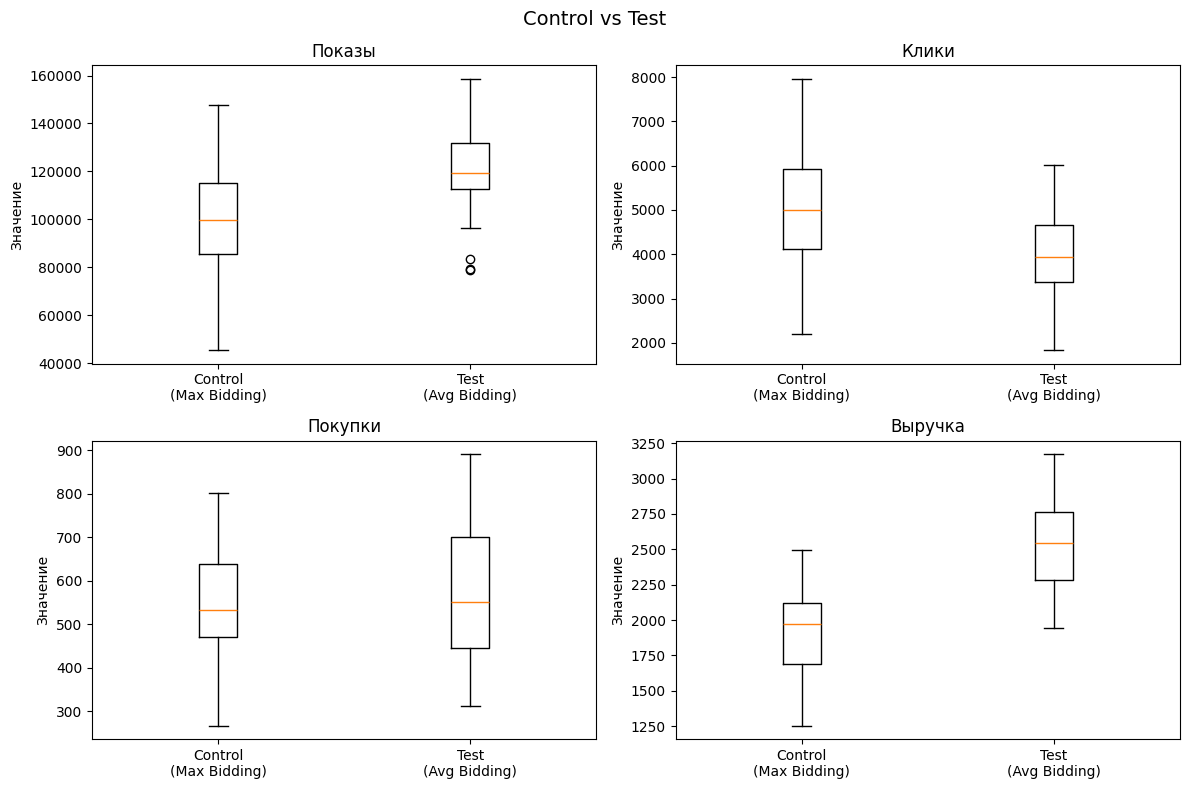

In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

metrics = ['Impression', 'Click', 'Purchase', 'Earning']
titles = ['Показы', 'Клики', 'Покупки', 'Выручка']

for i, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes[i//2][i%2]
    ax.boxplot([control[metric], test[metric]], labels=['Control\n(Max Bidding)', 'Test\n(Avg Bidding)'])
    ax.set_title(title)
    ax.set_ylabel('Значение')

plt.suptitle('Control vs Test', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:
from scipy import stats

print("Проверка нормальности (Shapiro-Wilk)")
print(f"{'Метрика':<12} {'Control p':>10} {'Test p':>10} {'Нормальное?':>12}")
print("-" * 48)

metrics = ['Impression', 'Click', 'Purchase', 'Earning']
names = ['Показы', 'Клики', 'Покупки', 'Выручка']

for metric, name in zip(metrics, names):
    _, p_control = stats.shapiro(control[metric])
    _, p_test = stats.shapiro(test[metric])
    normal = "ДА" if p_control > 0.05 and p_test > 0.05 else "НЕТ"
    print(f"{name:<12} {p_control:>10.4f} {p_test:>10.4f} {normal:>12}")

Проверка нормальности (Shapiro-Wilk)
Метрика       Control p     Test p  Нормальное?
------------------------------------------------
Показы           0.3514     0.4148           ДА
Клики            0.8458     0.9700           ДА
Покупки          0.5929     0.1541           ДА
Выручка          0.5313     0.6168           ДА


In [11]:
print(f"{'Метрика':<12} {'Control mean':>14} {'Test mean':>12} {'t-test p':>10} {'MW p':>10} {'Значимо?':>10}")
print("-" * 72)

for metric, name in zip(metrics, names):
    t_stat, t_p = stats.ttest_ind(control[metric], test[metric])
    mw_stat, mw_p = stats.mannwhitneyu(control[metric], test[metric], alternative='two-sided')
    significant = "ДА" if t_p < 0.05 else "нет"
    print(f"{name:<12} {control[metric].mean():>14.1f} {test[metric].mean():>12.1f} {t_p:>10.4f} {mw_p:>10.4f} {significant:>10}")

Метрика        Control mean    Test mean   t-test p       MW p   Значимо?
------------------------------------------------------------------------
Показы             101711.4     120512.4     0.0000     0.0001         ДА
Клики                5100.6       3967.6     0.0000     0.0001         ДА
Покупки               550.9        582.0     0.3503     0.4734        нет
Выручка              1908.6       2514.9     0.0000     0.0000         ДА


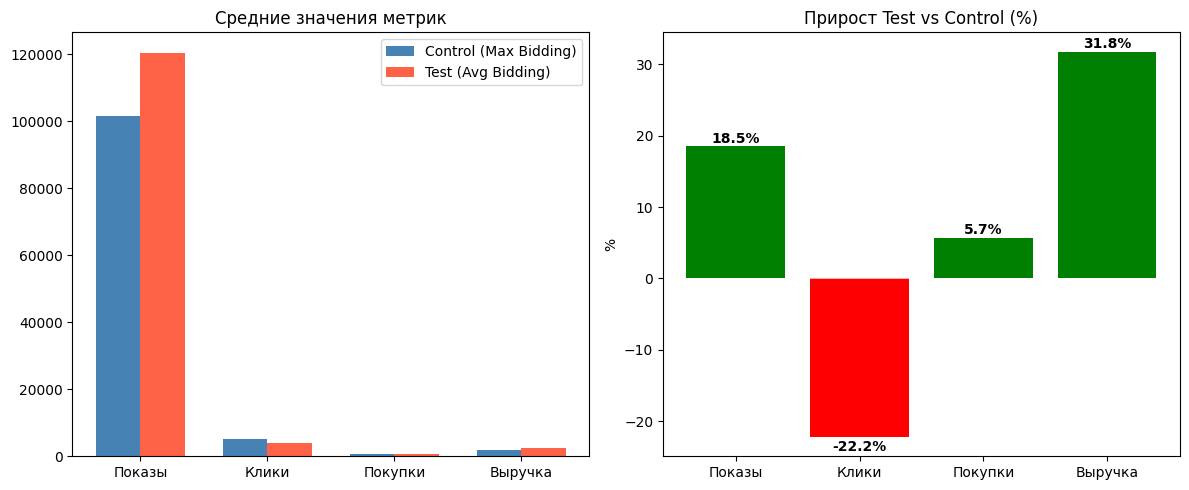

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Средние значения по метрикам
x = range(len(metrics))
width = 0.35
control_means = [control[m].mean() for m in metrics]
test_means = [test[m].mean() for m in metrics]

bars1 = axes[0].bar([i - width/2 for i in x], control_means, width, label='Control (Max Bidding)', color='steelblue')
bars2 = axes[0].bar([i + width/2 for i in x], test_means, width, label='Test (Avg Bidding)', color='tomato')
axes[0].set_xticks(list(x))
axes[0].set_xticklabels(names)
axes[0].set_title('Средние значения метрик')
axes[0].legend()

# Прирост в процентах
pct_change = [(test[m].mean() - control[m].mean()) / control[m].mean() * 100 for m in metrics]
colors = ['green' if p > 0 else 'red' for p in pct_change]
axes[1].bar(names, pct_change, color=colors)
axes[1].axhline(y=0, color='white', linestyle='-', linewidth=0.5)
axes[1].set_title('Прирост Test vs Control (%)')
axes[1].set_ylabel('%')
for i, v in enumerate(pct_change):
    axes[1].text(i, v + 0.5 if v > 0 else v - 2, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()